# Visualizing the results in images

Notebook for a visual analysis of the results. It makes the images for the papers comparing the different frameworks

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.polynomial.polynomial import polyfit
import matplotlib.gridspec as gridspec
import json

# make all images 800 dpi
plt.rcParams['savefig.dpi'] = 500
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# setup figsize
plt.rcParams['figure.figsize'] = (12, 6)
# setup title 
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.titleweight'] = 'bold'

# setup xlabel and ylabel in axes
plt.rcParams['axes.labelsize'] = 25

# setup ticks size
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

# setup legend size
plt.rcParams['legend.fontsize'] = 18
sns.set_style('whitegrid')

In [3]:
#datasets = list(sorted(['adult', 'Australian', 'cnae-9', 'credit-g', 'mfeat-factors', 'bank-marketing', 'Amazon_employee_access']))
datasets = list(sorted(['img_raw_tab','img_proj_tab','img_raw_features', '3planes_raw_features']))
#datasets = ['MedViT2-nopt']

In [4]:
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder, RobustScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from tpot.builtins import StackingEstimator
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tpot.export_utils import set_param_recursive

/home/beatrix/miniconda3/envs/carolina/lib/python3.10/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
save_path = os.path.join('..', 'results/MedViT2-nopt/exp3_mlp')
#save_path = os.path.join('..', 'results/img_raw_tab/exp2')
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [6]:
def format_thousands(x, pos):
    return f'{int(x/1000)}k'

In [7]:
source_path = os.path.join('..', 'data', 'results-csv')

## Evolution along Generations

In [8]:
frameworks = {
   'edca': 'EDCA'
}

In [9]:
values = {}
for dataset in datasets:
    values[dataset] = {framework: {} for framework in frameworks.keys()}

In [10]:
values = {dataset: {fw: {} for fw in frameworks.keys()} for dataset in datasets}

for dataset in datasets:
    for framework, label in frameworks.items():
        path = os.path.join('..','logs', 'MedViT2-nopt',dataset, 'exp3_mlp')
        #path = os.path.join('..','logs',dataset, 'img_raw_tab', 'exp2')
        for exp in os.listdir(path):
            for fold in range(1, 1+1):
                try:
                    bests = pd.read_csv(os.path.join(path, exp, 'edca', f'edca_fold{fold}', 'bests.csv'))
                    for m in [m for m in bests.columns if m not in ['Iteration','config']]:
                        values[dataset][framework][m] = values[dataset][framework].get(m, []) + [list(bests[m])]
                except:
                    continue



In [11]:
def get_mean_array(array, until_min=False):
    max_generations = max(len(v) for v in array)
    min_generations = min(len(v) for v in array)
    max_exps = len(array)

    data = np.zeros(shape=(max_exps, max_generations))
    data[::] = np.nan
    for i, v in enumerate(array):
        data[i, :len(v)] = v
    
    mean = np.nanmean(data, axis=0)
    if until_min:
        mean = mean[:min_generations]
    return mean

In [12]:
import math

def plot_evolution_along_generations(values, metric, ylabel, max_cols=2):
    sns.set_style('whitegrid')

    n = len(datasets)
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 5*nrows), sharey=False)

    # make axes always 2D for consistent indexing
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    legends = {}

    dataset_titles = {
    "3planes_raw_features": "iv)",
    "img_proj_tab": "ii)",
    "img_raw_features": "iii)",
    "img_raw_tab": "i)"
    }

    plot_order = [
    "img_raw_tab",
    "img_proj_tab",
    "img_raw_features",
    "3planes_raw_features"
    ]

    for idx, dataset in enumerate(plot_order):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r][c]

        for framework, label in frameworks.items():
            mean = get_mean_array(values[dataset][framework][metric], until_min=True)
            l = ax.plot(mean, label=label, lw=2)
            if label not in legends:
                legends[label] = l[0]

        ax.set_xlabel('Generation', fontdict=dict(size=16))
        ax.set_ylabel(ylabel, fontdict=dict(size=16))
        ax.set_title(dataset_titles.get(dataset, dataset), fontdict=dict(size=20, weight='bold'))
        ax.tick_params(axis='both', which='both', labelsize=14)

    # hide empty subplots if grid has extra slots
    for extra in range(n, nrows * ncols):
        r = extra // ncols
        c = extra % ncols
        axes[r][c].axis("off")

    fig.legend(
        handles=list(legends.values()),
        labels=list(legends.keys()),
        loc='lower center',
        ncol=len(legends),
        fontsize=16,
        bbox_to_anchor=(0.5, 0)
    )

    fig.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.savefig(os.path.join(save_path, f'evolution_along_generations_{metric}.png'), bbox_inches='tight')
    plt.show()


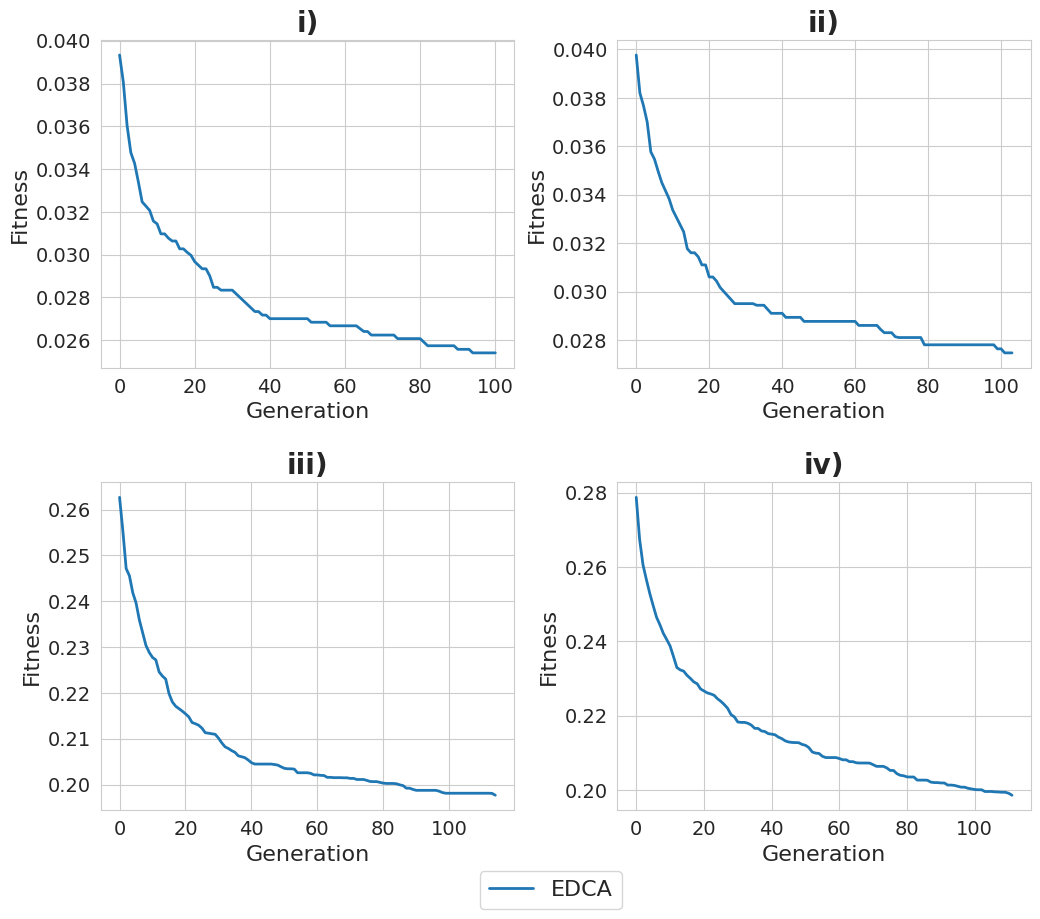

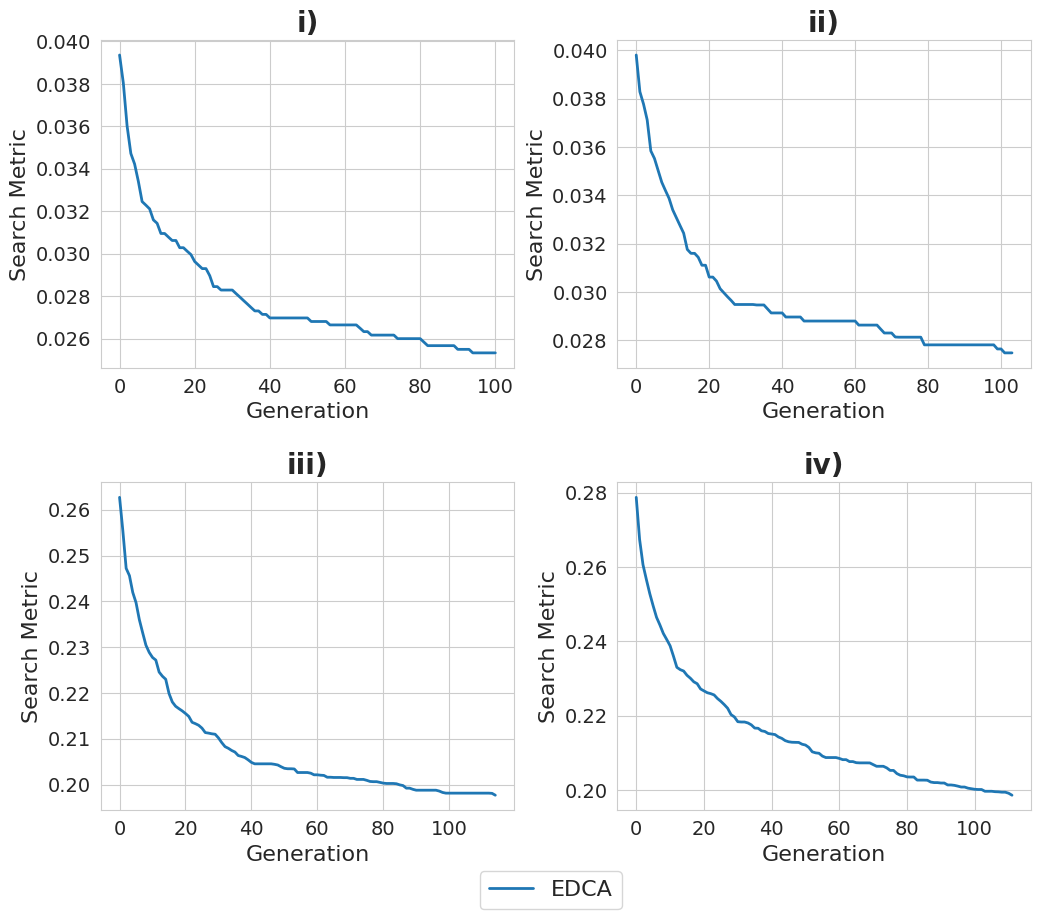

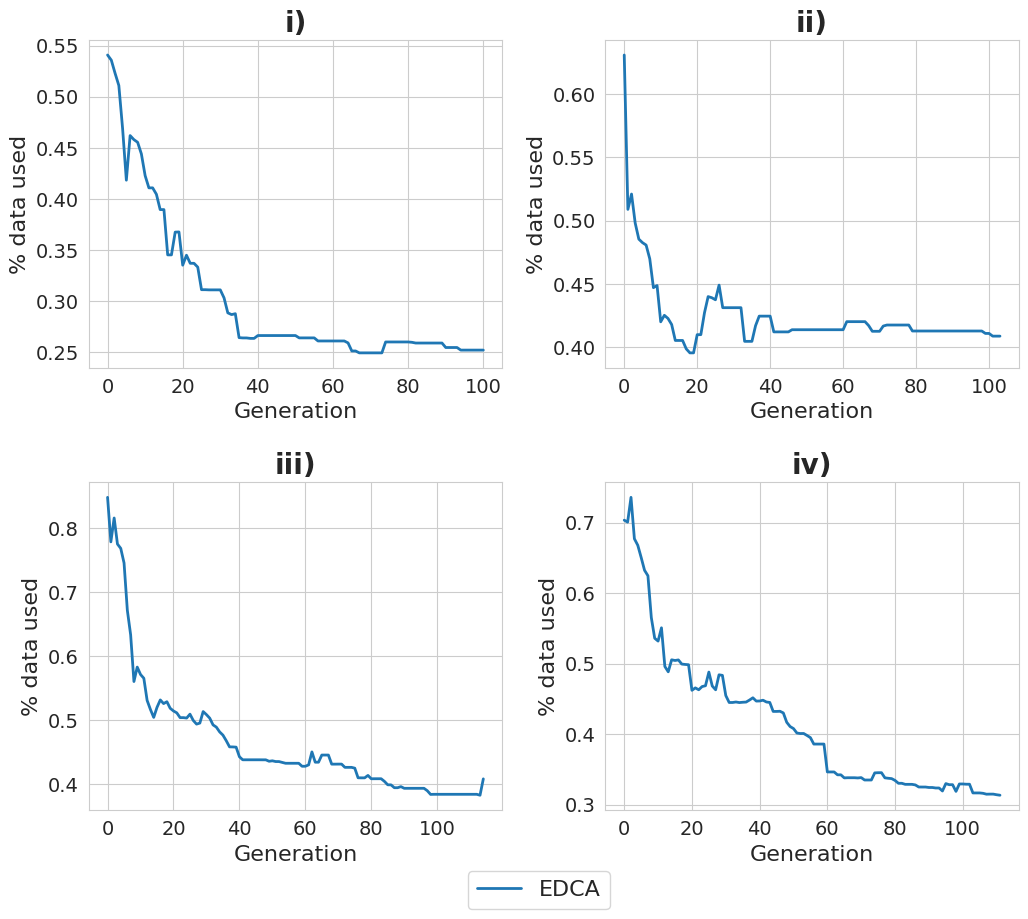

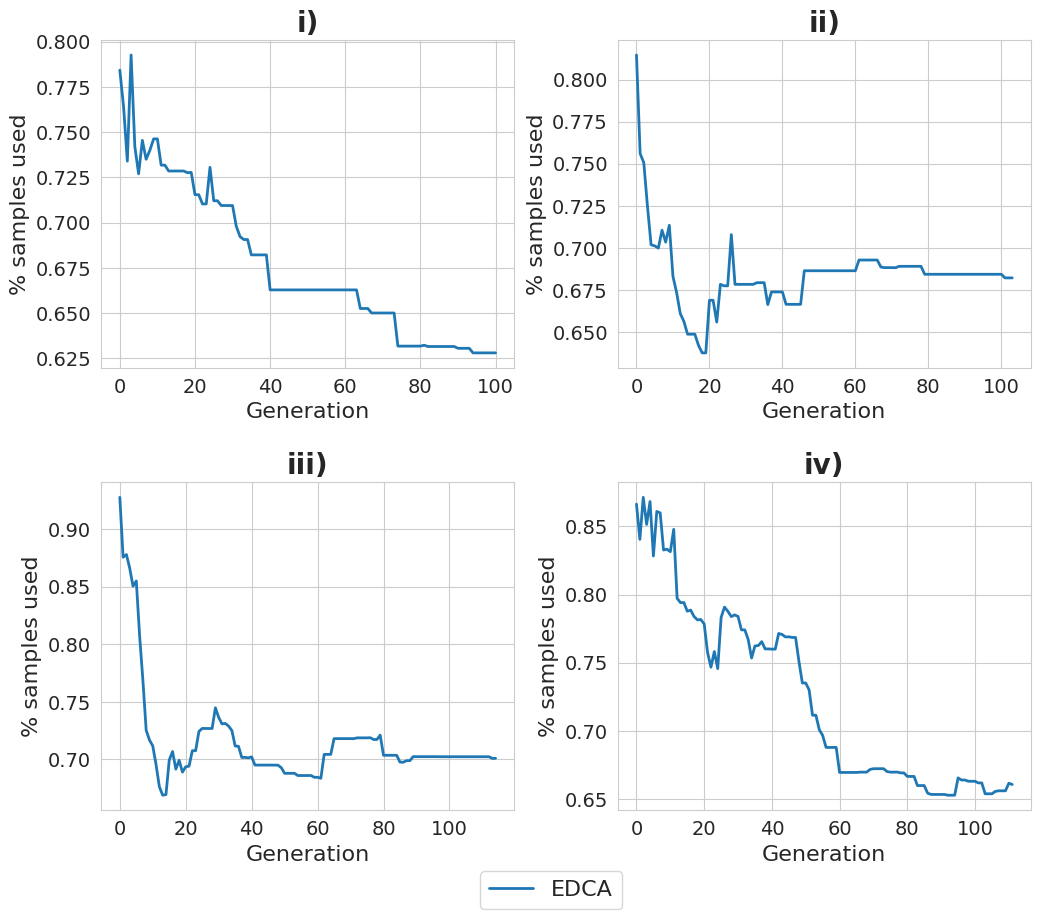

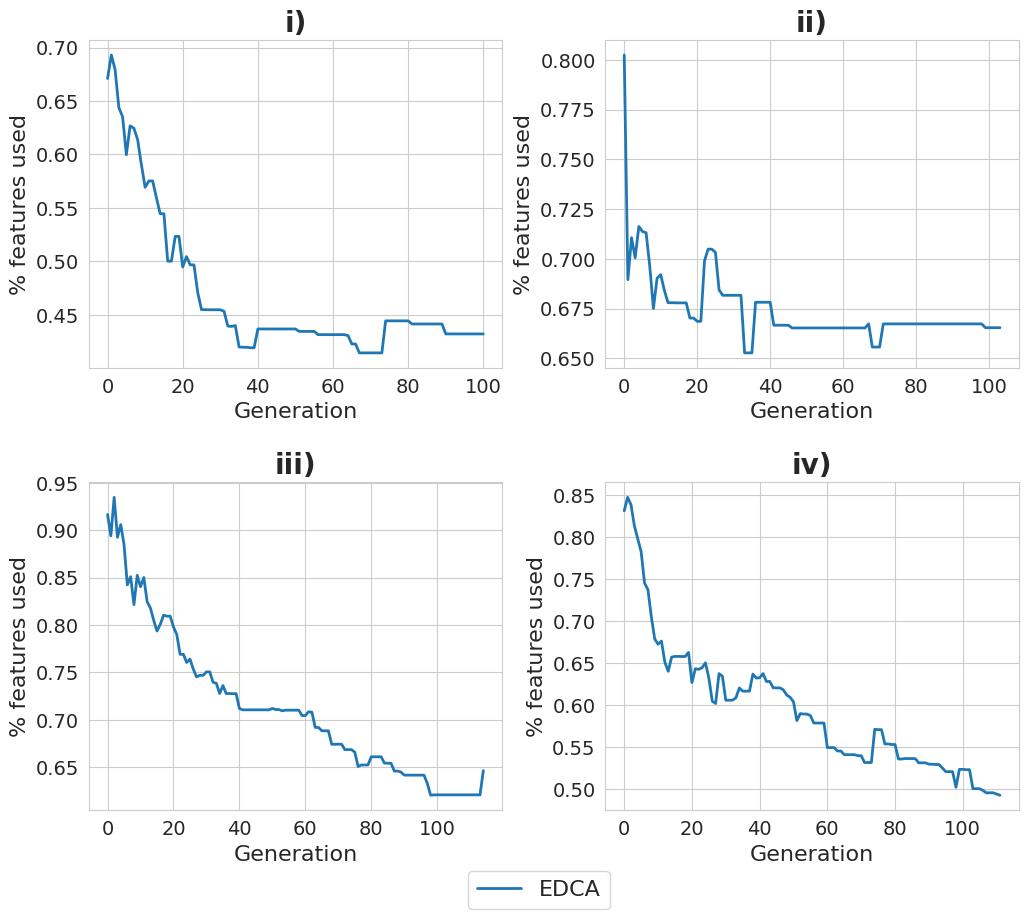

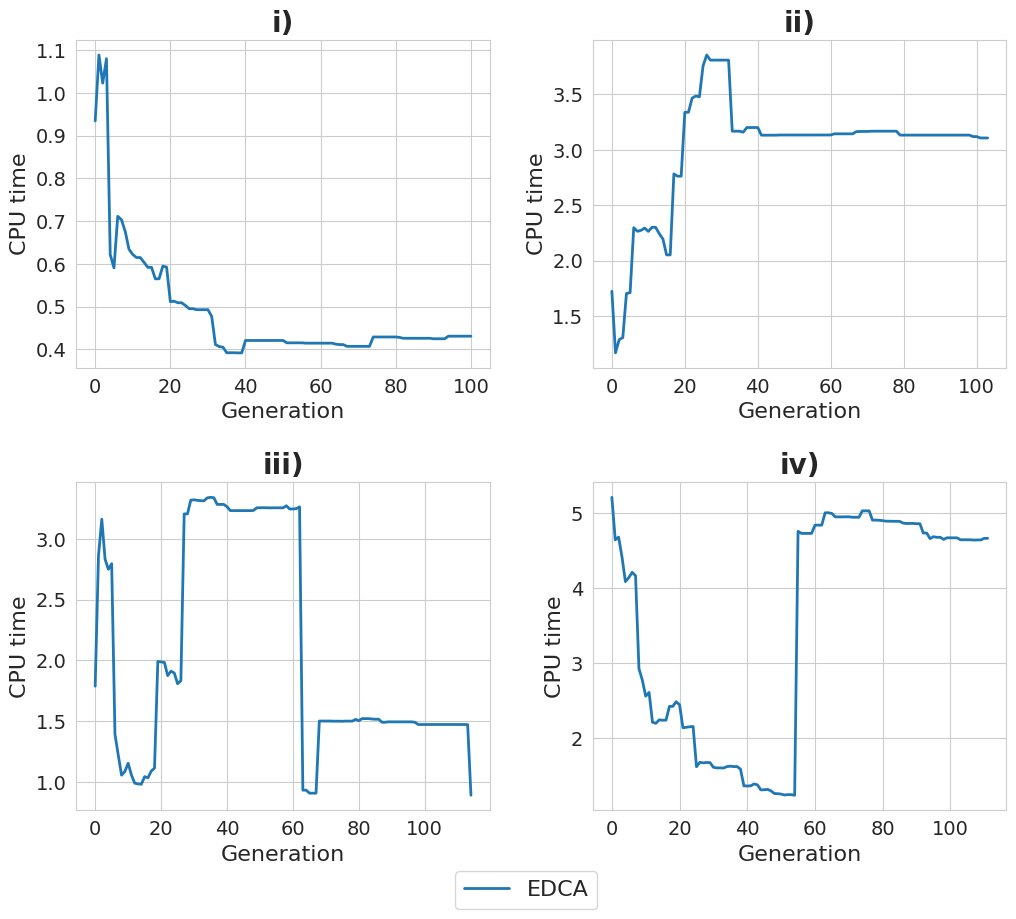

In [13]:
plot_evolution_along_generations(values, 'fitness', 'Fitness')
#plot_evolution_along_generations(values, 'inv_metric', 'Inverted MCC')
plot_evolution_along_generations(values, 'search_metric', 'Search Metric')
plot_evolution_along_generations(values, 'train_percentage', '% data used')
plot_evolution_along_generations(values, 'samples_percentage', '% samples used') 
plot_evolution_along_generations(values, 'features_percentage', '% features used')
plot_evolution_along_generations(values, 'time_cpu', 'CPU time')

## Bar charts with the percentage os models used

In [14]:
edca_models = {}

BASE = "../logs/MedViT2-nopt"  

for dataset in datasets:
    models = []

    exp1_dir = os.path.join(BASE, dataset, "exp3_mlp")
    runs = [d for d in sorted(os.listdir(exp1_dir)) if os.path.isdir(os.path.join(exp1_dir, d))]


    for run in runs:
        path = os.path.join(exp1_dir, run, "results.json")
        with open(path) as file:
            results = json.load(file)

        # model name is the key inside results["model"]
        best_model_dict = results["run_info"]["edca"]["best"]["model"]
        model_name = next(iter(best_model_dict.keys())) if best_model_dict else None

        models.append(model_name)

    edca_models[dataset] = models


In [15]:
possible_models = set()
for dataset in datasets:
    
    possible_models.update(set(edca_models[dataset]))

possible_models = list(possible_models)
possible_models = [m for m in possible_models if m is not None]
possible_models

['RandomForestClassifier',
 'LogisticRegression',
 'AdaBoostClassifier',
 'XGBClassifier',
 'MLPClassifier',
 'ExtraTreesClassifier',
 'DecisionTreeClassifier']

In [16]:
palette = sns.color_palette(n_colors=len(possible_models))

color_mapping = dict(zip(possible_models, palette))

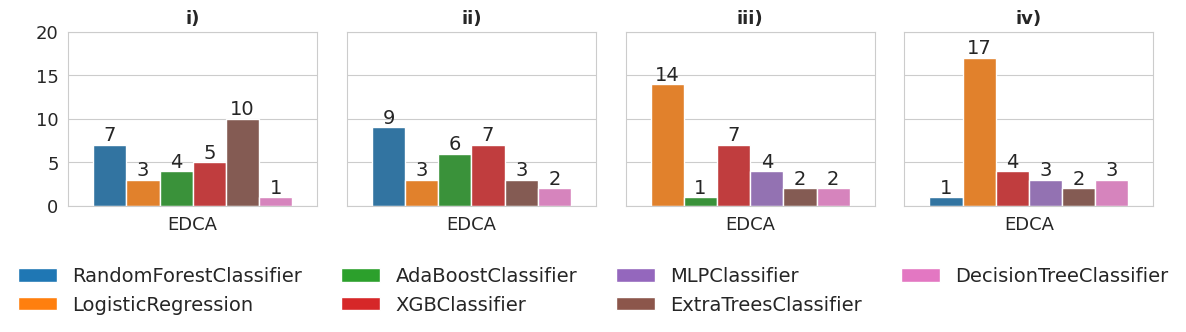

In [17]:
from matplotlib.patches import Patch

dataset_order = [
    "img_raw_tab",
    "img_proj_tab",
    "img_raw_features",
    "3planes_raw_features"
]
'''
dataset_display_names = {
    "img_raw_tab": "Image emb + Tabular emb",
    "img_proj_tab": "Image emb + Projected Tabular emb",
    "img_raw_features": "Image emb + Tabular features",
    "3planes_raw_features": "Head emb + Femur emb + Abdomen emb + Tabular features"
}'''

dataset_display_names = {
    "img_raw_tab": "i)",
    "img_proj_tab": "ii)",
    "img_raw_features": "iii)",
    "3planes_raw_features": "iv)"
}

ncols = 4
#nrows = int(np.ceil(len(dataset_order) / ncols))
nrows = 1
#fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6), sharey=True)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3), sharey=True)
sns.set_style('whitegrid')
axes = np.array(axes).ravel()

# global y-limit across all datasets
global_max = 0
counts_per_dataset = {}

for ds in dataset_order:
    df = pd.DataFrame({
        'Framework': ['EDCA'] * len(edca_models[ds]),
        'Model': edca_models[ds]
    }).dropna(subset=['Model'])

    categories_count = (
        df.groupby(['Framework', 'Model'])
          .size()
          .reset_index(name='Count')
    )

    counts_per_dataset[ds] = categories_count
    if not categories_count.empty:
        global_max = max(global_max, categories_count['Count'].max())

global_ylim = int(np.ceil(global_max / 5.0) * 5)

for i, ds in enumerate(dataset_order):
    ax = axes[i]
    categories_count = counts_per_dataset[ds]

    # only models that appear in this dataset
    local_models = [m for m in possible_models if m in categories_count['Model'].unique()]

    sns.barplot(
        x='Framework',
        y='Count',
        hue='Model',
        data=categories_count,
        order=['EDCA'],
        hue_order=local_models,
        ax=ax,
        palette=color_mapping
    )

    for p in ax.patches:
        value = p.get_height()
        if not np.isnan(value) and value > 0:
            ax.annotate(
                f'{int(value)}',
                (p.get_x() + p.get_width() / 2., value),
                ha='center',
                va='bottom',
                fontsize=14
            )

    ax.set_title(dataset_display_names[ds], fontdict=dict(size=13, weight='bold'))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='both', which='both', labelsize=13)
    ax.set_ylim(0, global_ylim)
    ax.legend().set_visible(False)

# hide unused axes
for j in range(len(dataset_order), len(axes)):
    axes[j].set_visible(False)

legend_handles = [Patch(facecolor=color_mapping[m], label=m) for m in possible_models]

fig.legend(
    legend_handles,
    possible_models,
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,  
    fontsize=14,
    title_fontsize=11,
    frameon=False
)
plt.subplots_adjust(hspace=0.2, wspace=0.12, bottom=0.3)
plt.savefig(os.path.join(save_path, 'histogram_final_models_frameworks.png'), bbox_inches='tight')
plt.savefig(os.path.join(save_path, 'histogram_final_models_frameworks.eps'), bbox_inches='tight', format='eps')
plt.show()

Bar charts with the percentage of Data Reduction 

In [18]:
frameworks = {
    'edca' : 'EDCA',
}

def get_model(individual):
    return list(individual['model'].keys())[0]

def get_dr_used(individual):
    only_sample = 0
    only_features = 0
    both_dr = 0
    without_dr = 0
    if 'sample' in individual and 'features' not in individual:
        only_sample = 1
    elif 'features' in individual and 'sample' not in individual:
        only_features = 1
    elif 'sample' in individual and 'features' in individual:
        both_dr = 1
    else:
        without_dr = 1
    return only_sample, only_features, both_dr, without_dr

In [19]:
data_models = {}
for dataset in datasets:
    data_models[dataset] = {framework: [] for framework in frameworks}

data_dr = {}
for dataset in datasets:
    data_dr[dataset] = {}
    for framework in frameworks:
        data_dr[dataset][framework] = {}
        for setup in ['Only IS', 'Only FS', 'IS and FS', 'Without DR']:
            data_dr[dataset][framework][setup] = 0

In [20]:
for dataset in datasets:
    for framework in list(frameworks.keys()):
        base_path = os.path.join("..", "logs", "MedViT2-nopt", dataset, "exp3_mlp")
        runs = sorted([d for d in os.listdir(base_path) if d.startswith("exp_")])
        for run in runs:
            path = os.path.join(base_path, run, "results.json")
            #path = os.path.join(base_path, run, 'edca', 'edca_fold1','evaluated_individuals.csv')
            with open(path) as file:
                results = json.load(file)

            individual = results.get("run_info", {}).get("edca", {}).get("best")

            if individual is not None:
                model = get_model(individual)
                data_models[dataset][framework].append(model)
                only_sample, only_features, both_dr, without_dr = get_dr_used(individual)
                data_dr[dataset][framework]['Only IS'] += only_sample
                data_dr[dataset][framework]['Only FS'] += only_features
                data_dr[dataset][framework]['IS and FS'] += both_dr
                data_dr[dataset][framework]['Without DR'] += without_dr

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


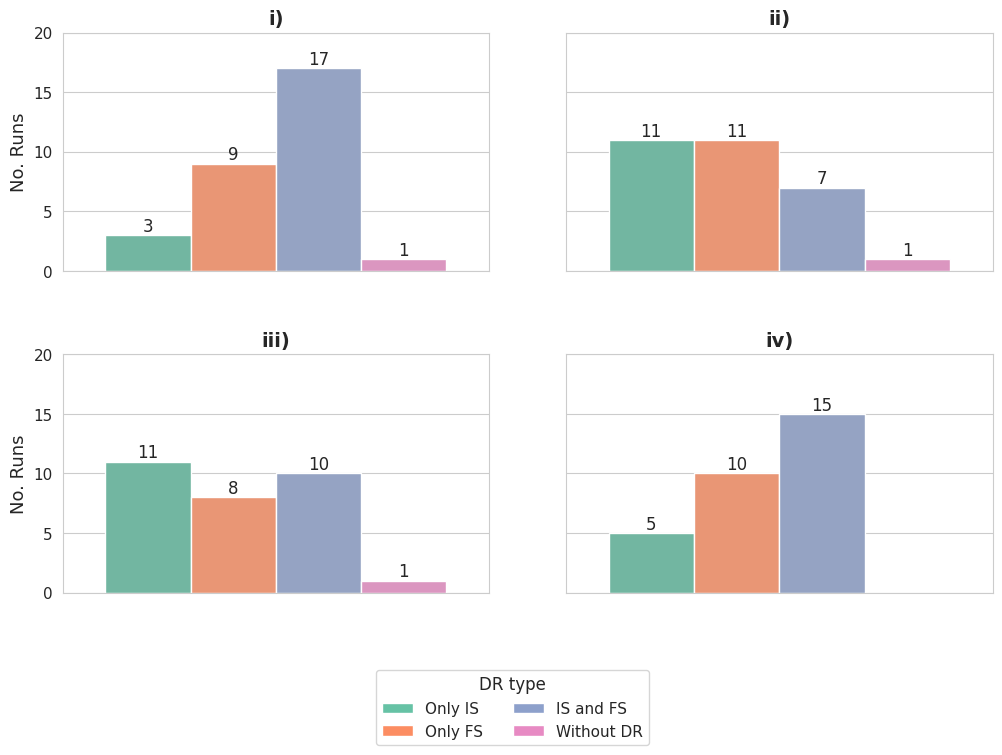

In [21]:
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

show_framework = 'edca'
possible_dr = ['Only IS', 'Only FS', 'IS and FS', 'Without DR']

dataset_order = [
    "img_raw_tab",
    "img_proj_tab",
    "img_raw_features",
    "3planes_raw_features"
]
'''
dataset_display_names = {
    "img_raw_tab": "Image emb + Tabular emb",
    "img_proj_tab": "Image emb + Projected Tabular emb",
    "img_raw_features": "Image emb + Tabular features",
    "3planes_raw_features": "Head emb + Femur emb + Abdomen emb + Tabular features"
}'''

dataset_display_names = {
    "img_raw_tab": "i)",
    "img_proj_tab": "ii)",
    "img_raw_features": "iii)",
    "3planes_raw_features": "iv)"
}

dr_palette = sns.color_palette("Set2", n_colors=len(possible_dr))
dr_color_mapping = dict(zip(possible_dr, dr_palette))

ncols = 2
nrows = int(np.ceil(len(dataset_order) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8), sharey=True)
sns.set_style("whitegrid")
axes = np.array(axes).ravel()

# compute global max for equal y-scale
global_max = 0
plot_data = {}

for dataset in dataset_order:
    df = pd.DataFrame(data_dr[dataset])[show_framework].to_frame()
    df.columns = [frameworks[framework] for framework in df.columns]
    df.index.name = "DR applied"

    df_melted = df.reset_index().melt(
        id_vars="DR applied",
        var_name="Framework",
        value_name="Count"
    )

    plot_data[dataset] = df_melted
    if not df_melted.empty:
        global_max = max(global_max, df_melted["Count"].max())

global_ylim = int(np.ceil(global_max / 5.0) * 5)

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    df_melted = plot_data[dataset]

    sns.barplot(
        x="Framework",
        y="Count",
        hue="DR applied",
        data=df_melted,
        order=df_melted["Framework"].unique(),
        hue_order=possible_dr,
        palette=dr_color_mapping,
        ax=ax
    )

    for p in ax.patches:
        value = p.get_height()
        if not np.isnan(value) and value > 0:
            ax.annotate(
                f"{int(value)}",
                (p.get_x() + p.get_width() / 2., value),
                ha="center",
                va="bottom",
                fontsize=12
            )

    ax.set_title(dataset_display_names.get(dataset, dataset), fontdict=dict(size=14, weight='bold'))
    ax.set_xlabel("")
    ax.set_ylabel("" if i % ncols else "No. Runs", fontdict=dict(size=13))
    ax.set_xticklabels([])
    ax.tick_params(axis='both', labelsize=11)
    ax.set_ylim(0, global_ylim)
    ax.legend().set_visible(False)

# hide unused axes
for j in range(len(dataset_order), len(axes)):
    axes[j].set_visible(False)

legend_handles = [Patch(facecolor=dr_color_mapping[cat], label=cat) for cat in possible_dr]
fig.legend(
    handles=legend_handles,
    labels=possible_dr,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=11,
    title="DR type",
    title_fontsize=12
)

plt.subplots_adjust(hspace=0.35, wspace=0.18, bottom=0.18)
plt.savefig(os.path.join(save_path, f"histogram_{show_framework}_dr_techniques.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_path, f"histogram_{show_framework}_dr_techniques.eps"), bbox_inches="tight", format="eps")
plt.show()

In [22]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from json import JSONDecodeError

LOGS_ROOT = os.path.join("..", "logs", "MedViT2-nopt")
datasets = [
    "img_raw_tab",
    "img_proj_tab",
    "img_raw_features",
    "3planes_raw_features",
]
experimentation_name = "exp3_mlp"
save_path = os.path.join("..", "results", "plots")
os.makedirs(save_path, exist_ok=True)


def load_reduction_percents_from_run(run_dir, framework="edca"):
    fp = os.path.join(run_dir, "results.json")
    if not os.path.isfile(fp):
        return None

    try:
        with open(fp, "r") as f:
            r = json.load(f)
    except JSONDecodeError:
        print(f"Skipping invalid JSON: {fp}")
        return None

    info = r.get("run_info", {}).get(framework, {})
    if not info:
        return None

    return {
        "sample_%": info.get("sample_%", np.nan),
        "features_%": info.get("features_%", np.nan),
        "data_%": info.get("data_%", np.nan),
    }


rows = []

for dataset in datasets:
    exp_dir = os.path.join(LOGS_ROOT, dataset, experimentation_name)
    if not os.path.isdir(exp_dir):
        print(f"Skipping missing folder: {exp_dir}")
        continue

    run_dirs = sorted([
        os.path.join(exp_dir, d)
        for d in os.listdir(exp_dir)
        if d.startswith("exp_") and os.path.isdir(os.path.join(exp_dir, d))
    ])

    for run_dir in run_dirs:
        vals = load_reduction_percents_from_run(run_dir, framework="edca")
        if vals is None:
            continue

        rows.append({
            "dataset": dataset,
            "run": os.path.basename(run_dir),
            "metric": "data_%",
            "value": vals["data_%"]*100,
        })
        rows.append({
            "dataset": dataset,
            "run": os.path.basename(run_dir),
            "metric": "sample_%",
            "value": vals["sample_%"] *100,
        })
        rows.append({
            "dataset": dataset,
            "run": os.path.basename(run_dir),
            "metric": "features_%",
            "value": vals["features_%"] *100,
        })

df_long = pd.DataFrame(rows)

# nicer labels
label_map = {
    "data_%": "% Data",
    "sample_%": "% Samples",
    "features_%": "% Features",
}
df_long["metric"] = df_long["metric"].map(label_map)

dataset_name_map = {
    "img_raw_tab": "i)",
    "img_proj_tab": "ii)",
    "img_raw_features": "iii)",
    "3planes_raw_features": "iv)",
}
df_long["dataset_pretty"] = df_long["dataset"].map(dataset_name_map).fillna(df_long["dataset"])

# print means and std
summary = (
    df_long.groupby(["dataset_pretty", "metric"])["value"]
    .agg(["mean", "std", "median", "min", "max"])
    .round(2)
)
print("\nSummary statistics:\n")
print(summary)




Summary statistics:

                            mean    std  median    min     max
dataset_pretty metric                                         
i)             % Data      21.94  20.50   20.55   0.23  100.00
               % Features  43.81  33.22   31.15   2.29  100.00
               % Samples   55.70  34.32   44.06   8.91  100.00
ii)            % Data      34.93  27.72   27.60   1.92  100.00
               % Features  65.05  38.10   87.76   4.56  100.00
               % Samples   61.30  33.90   46.91  13.74  100.00
iii)           % Data      33.39  21.27   31.43   4.19  100.00
               % Features  64.60  35.57   70.35   4.19  100.00
               % Samples   59.86  29.31   49.81  12.87  100.00
iv)            % Data      24.55  21.09   18.95   2.49   87.65
               % Features  49.43  36.90   32.87   3.21  100.00
               % Samples   56.81  33.17   41.96  10.77  100.00


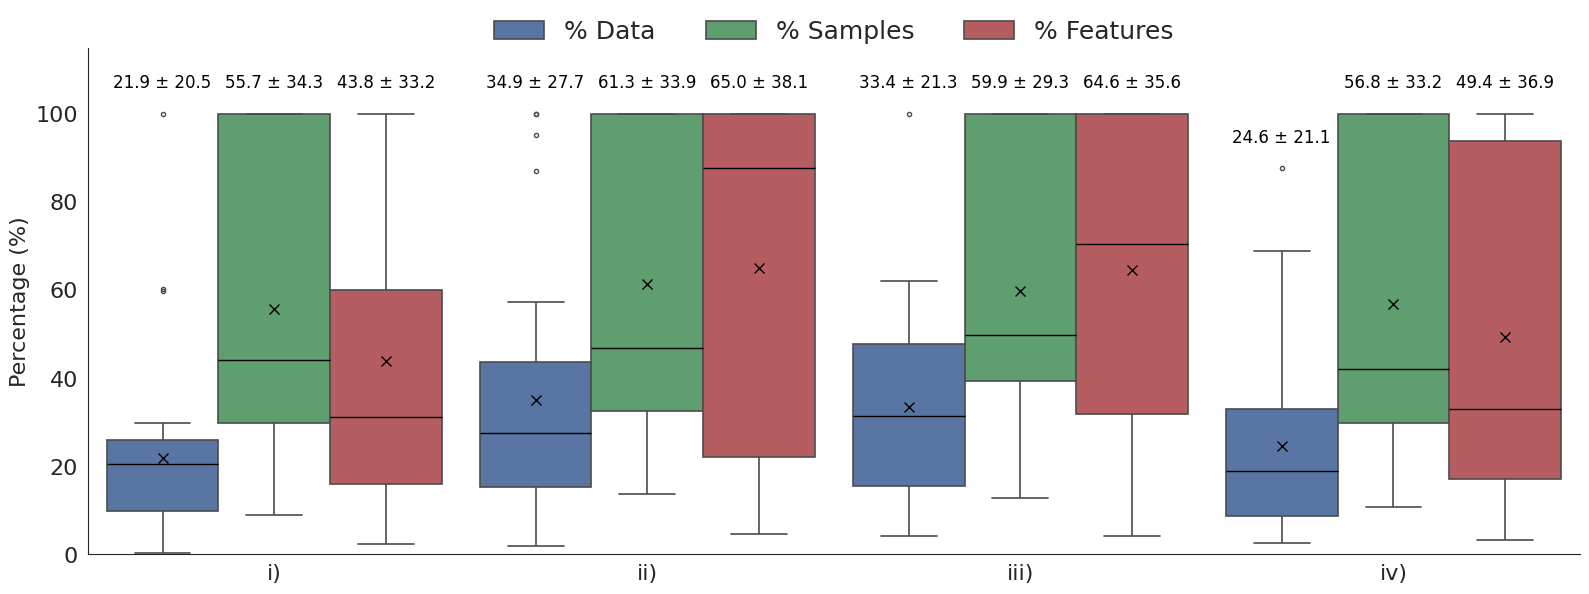

<Figure size 1200x600 with 0 Axes>

In [37]:
# --- Styling ---
plt.rcParams['font.family'] = 'serif'
sns.set_style("white")

# Softer versions of your original palette
soft_palette = {
    "% Data": "#4C72B0",

    "% Samples": "#55A868",

    "% Features": "#C44E52"
}

plt.figure(figsize=(16, 6)) # Wider figure to give boxes room
ax = plt.gca()
sns.despine()

# 1. Increase width to 0.8 to make boxes larger
width = 0.9
hue_order = ["% Data", "% Samples", "% Features"]
order = sorted(df_long["dataset_pretty"].unique())

ax = sns.boxplot(
    data=df_long,
    x="dataset_pretty",
    y="value",
    hue="metric",
    order=order,
    hue_order=hue_order,
    palette=soft_palette,
    width=width,
    linewidth=1.2,
    showmeans=True,
    #meanline=True,
    showfliers=True,
    fliersize=3,
   
    medianprops={"color": "#000000", "linewidth": 1}, 
    meanprops={
        #"linestyle": "--",
        "marker":"x",
        #"linewidth": 1,
        #"color": "000000"
        "markeredgecolor": "black",
        "markersize": "7"}

    
)


# 2. Set Y-axis to 100%
ax.set_ylim(0, 115) # 115 gives a little "breathing room" for labels at the top

# 3. Improved Annotation Logic
summary = df_long.groupby(["dataset_pretty", "metric"])["value"].agg(["mean", "std", "max"]).reset_index()

n_hues = len(hue_order)
# Calculate offsets manually to place text exactly over each box
offsets = np.linspace(-width/2 + width/(2*n_hues), width/2 - width/(2*n_hues), n_hues)

for i, ds in enumerate(order):
    for j, m in enumerate(hue_order):
        stats = summary[(summary["dataset_pretty"] == ds) & (summary["metric"] == m)]
        if stats.empty: continue
        
        mean_val = stats["mean"].values[0]
        std_val = stats["std"].values[0]
        max_val = stats["max"].values[0]
        
        curr_x = i + offsets[j]
        
        # Place text slightly above the top of the whisker (max) or box
        # We use a small offset relative to the data
        ax.text(
            curr_x,
            min(max_val + 5, 110),
            f"{mean_val:.1f} ± {std_val:.1f}",
            ha="center",
            va="bottom",
            fontsize=12,
            color="#000000"
        )

        # Std (smaller, slightly to the right and above baseline)
        #ax.text(
            #curr_x,
            #min(max_val + 5, 110),
            #f" 士 {std_val:.1f}",
            #ha="left",            # shift to the right of mean
            #va="bottom",
            #fontsize=11,           # smaller font
            #color="#000000",
            #)

# --- Labels & Legend ---
ax.set_ylabel("Percentage (%)", fontsize=16)
ax.set_xlabel("")
plt.xticks(fontsize=16)
plt.yticks (fontsize=16)
ax.legend(
    loc="upper center", 
    bbox_to_anchor=(0.5, 1.10),
    ncol=3, 
    frameon=False,
    fontsize=18
)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(save_path, "edca_reduction_boxplot.pdf")) 


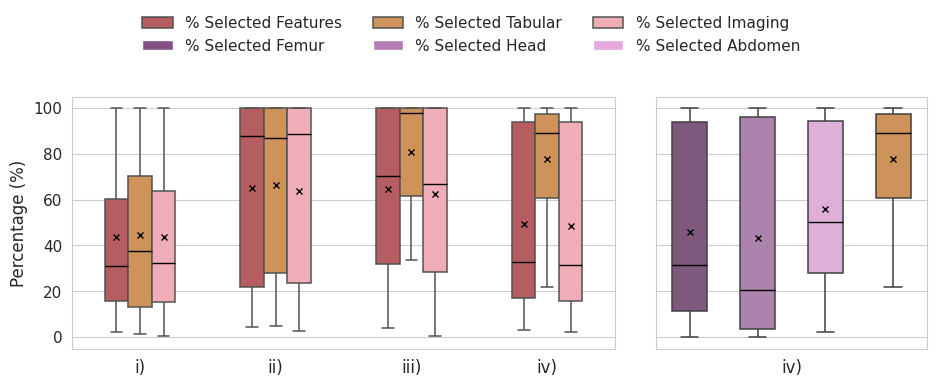

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

files = {
    "i)": "../results/img_raw_tab/exp3_mlp/embedding_type_percentages_per_run.csv",
    "ii)": "../results/img_proj_tab/exp3_mlp/embedding_type_percentages_per_run.csv",
    "iii)": "../results/img_raw_features/exp3_mlp/embedding_type_percentages_per_run.csv",
    "iv)": "../results/3planes_raw_features/exp3_mlp/3planes_feature_counts_and_percentages_per_experiment.csv",
}

rows = []

for dataset, path in files.items():
    df = pd.read_csv(path)

    df = df[~df["run"].isin(["MEAN", "STD"])] if "run" in df.columns else df[~df["experiment"].isin(["MEAN", "STD"])]

    for _, r in df.iterrows():
        rows.append({
            "dataset": dataset,
            "metric": "% Selected Features",
            "value": r.get("total_%_of_all_features", r.get("total_features_%_of_all")),
        })
        rows.append({
            "dataset": dataset,
            "metric": "% Selected Tabular",
            "value": r.get("tab_%_of_all_tab_features", r.get("tabular_%_of_all_tabular")),
        })
        rows.append({
            "dataset": dataset,
            "metric": "% Selected Imaging",
            "value": r.get("img_%_of_all_img_features", r.get("image_total_%_of_all_image")),
        })

df_left = pd.DataFrame(rows)


df = pd.read_csv("../results/3planes_raw_features/exp3_mlp/3planes_feature_counts_and_percentages_per_experiment.csv")
df = df[~df["experiment"].isin(["MEAN", "STD"])]

rows = []
for _, r in df.iterrows():
    rows.append({"metric": "% Selected Femur", "value": r["femur_%_of_all_femur"]})
    rows.append({"metric": "% Selected Head", "value": r["head_%_of_all_head"]})
    rows.append({"metric": "% Selected Abdomen", "value": r["abdomen_%_of_all_abdomen"]})
    rows.append({"metric": "% Selected Tabular", "value": r["tabular_%_of_all_tabular"]})

df_right = pd.DataFrame(rows)


palette_left = {
    "% Selected Features": "#C44E52",   # neutral/red
    "% Selected Tabular": "#E09248",    # orange
    "% Selected Imaging": "#FAA2B1",    # blue
}

palette_right = {
    "% Selected Femur": "#855183",
    "% Selected Head": "#B37CB3",
    "% Selected Abdomen": "#E6A8DD",
    "% Selected Tabular": "#E09248",
}

fig, axes = plt.subplots(
    1, 2,
    figsize=(9.5, 4.2),
    sharey=True,
    gridspec_kw={'width_ratios': [2, 1]}
)


# --- Left Boxplot ---
sns.boxplot(
    data=df_left,
    x="dataset",
    y="value",
    hue="metric",
    palette=palette_left,
    width=0.52,
    linewidth=1.1,
    fliersize=3.5,
    showmeans=True,
    #meanline=True,  
    meanprops={
        #"linestyle": "--",
        #"linewidth": 1,
        #"color": "000000"
        "marker":"x",
        "markeredgecolor": "black",
        "markersize": "4"},
    
    medianprops={"color": "#000000", "linewidth": 1},
    ax=axes[0]
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Percentage (%)", fontsize=12)
axes[0].tick_params(axis="x", labelsize=12)
axes[0].tick_params(axis="y", labelsize=11)


# --- Right Boxplot ---
sns.boxplot(
    data=df_right,
    x="metric",
    y="value",
    hue="metric",           
    palette=palette_right,
    width=0.52,
    linewidth=1.1,
    fliersize=3.5,
    dodge=False,           
    showmeans=True,
    #meanline=True,  
    meanprops={
        #"linestyle": "--",
        #"linewidth": 1,
        #"color": "000000"
        "marker":"x",
        "markeredgecolor": "black",
        "markersize": "4"},
    
    medianprops={"color": "#000000", "linewidth": 1},
    ax=axes[1]
)

axes[1].set_xlabel("iv)", fontsize=12)
axes[1].set_xticklabels([])  
axes[1].tick_params(axis="x", length=0) 

from matplotlib.patches import Patch

order = [
    "% Selected Features",
    "% Selected Femur",
    "% Selected Tabular", 
    "% Selected Head",
    "% Selected Imaging",
    
    
    "% Selected Abdomen",
]

handles_left, labels_left = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
if axes[1].legend_:
    axes[1].legend_.remove()

# Manually define right-side handles (excluding % Selected Tabular, already in left)
extra_handles = [
    Patch(facecolor=palette_right["% Selected Femur"],   label="% Selected Femur"),
    Patch(facecolor=palette_right["% Selected Head"],    label="% Selected Head"),
    Patch(facecolor=palette_right["% Selected Abdomen"], label="% Selected Abdomen"),
]
extra_labels = ["% Selected Femur", "% Selected Head", "% Selected Abdomen"]

# Build a dict for easy lookup
handle_dict = dict(zip(labels_left + extra_labels, handles_left + extra_handles))

# Reorder
handles = [handle_dict[l] for l in order]
labels  = order

legend = fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.85),
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.subplots_adjust(top=0.78, bottom=0.18, left=0.08, right=0.98, wspace=0.10)

plt.savefig(
    "../results/combined_feature_selection_boxplots.png",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=[legend]
)

plt.savefig(
    "../results/combined_feature_selection_boxplots.pdf",
    bbox_inches="tight",
    bbox_extra_artists=[legend]
)

plt.show()

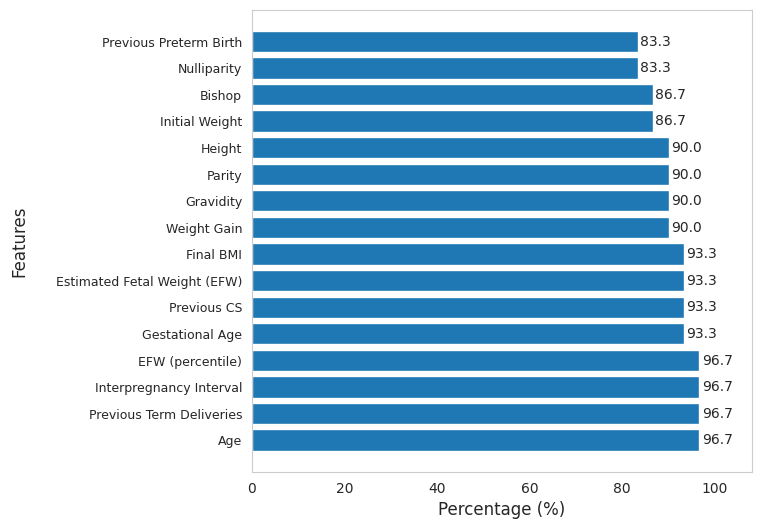

In [25]:
import matplotlib.pyplot as plt

# Data (original order preserved)
features = [
    "Age",
    "Previous Term Deliveries",
    "Interpregnancy Interval",
    "EFW (percentile)",
    "Gestational Age",
    "Previous CS",
    "Estimated Fetal Weight (EFW)",
    "Final BMI",
    "Weight Gain",
    "Gravidity",
    "Parity",
    "Height",
    "Initial Weight",
    "Bishop",
    "Nulliparity",
    "Previous Preterm Birth"
]

percentages = [
    96.67, 96.67, 96.67, 96.67,
    93.33, 93.33, 93.33, 93.33,
    90, 90, 90, 90,
    86.67, 86.67,
    83.33, 83.33
]

# Optional: wrap long labels for better readability
import textwrap
features = ["\n".join(textwrap.wrap(f, 20)) for f in features]

import matplotlib.pyplot as plt
import textwrap

# ... (your data remains the same) ...

# 1. CHANGE: Increase the width of the figure. 
# A wider figure gives more absolute pixels to the left margin.
plt.figure(figsize=(10, 6)) 

# Optional: wrap labels slightly wider if you want them on fewer lines
features_wrapped = ["\n".join(textwrap.wrap(f, 30)) for f in features]

plt.barh(features_wrapped, percentages)

# 2. CHANGE: Manually adjust the left margin.
# 'left=0.4' means the plot starts at 40% of the figure width, 
# leaving 40% for the labels.
plt.subplots_adjust(left=0.5, right=1)

# Labels
plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Features",labelpad=20, fontsize=12)

# Tick sizes
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)

plt.grid(False)
plt.xlim(0, 108)

for i, v in enumerate(percentages):
    plt.text(v + 0.5, i, f"{v:.1f}", va='center', fontsize=10)

# 3. CRITICAL: Use plt.savefig with bbox_inches='tight' 
# but AFTER subplots_adjust.
plt.savefig("feature_plot.pdf", dpi=300, bbox_inches='tight')

plt.show()